# Analyse de la taille du marché des véhicules électriques avec Python

L'analyse de la taille du marché est un aspect crucial des études de marché. Elle permet de déterminer le volume de ventes potentiel d'un marché donné. Elle aide les entreprises à comprendre l'ampleur de la demande, à évaluer les niveaux de saturation du marché et à identifier les opportunités de croissance. Si vous souhaitez apprendre à réaliser une analyse de la taille du marché de n'importe quel produit, cet article est fait pour vous. Dans cet article, je vous expliquerai comment analyser la taille du marché des véhicules électriques avec Python.

# Analyse du marché des véhicules électriques : processus à suivre

L'analyse de la taille du marché des véhicules électriques implique un processus en plusieurs étapes, comprenant la définition du périmètre du marché, la collecte et la préparation des données, la modélisation analytique et la communication des résultats par le biais de visualisations et de rapports. Voici la procédure à suivre pour cette analyse :

1. Définissez si l’analyse est globale, régionale ou axée sur des pays spécifiques.

2. Recueillez des informations auprès des associations industrielles, des sociétés d’études de marché (par exemple, BloombergNEF, IEA) et des publications gouvernementales pertinentes pour le marché des véhicules électriques.

3. Utilisez des données historiques pour identifier les tendances en matière de ventes, de production et de marché des véhicules électriques.

4. Analyser la taille du marché et les taux de croissance pour différents segments de véhicules électriques.

5. Sur la base de l’analyse de la taille du marché, fournissez des recommandations stratégiques aux entreprises qui cherchent à entrer ou à se développer sur le marché des véhicules électriques.

Nous avons donc besoin d'un ensemble de données adapté à l'analyse de la taille du marché des véhicules électriques.

Commençons maintenant par la tâche d'analyse de la taille du marché des véhicules électriques en important les bibliothèques Python nécessaires et l' ensemble de données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from scipy.optimize import curve_fit
#rom google.colab import files
# Permettre à l'utilisateur de télécharger un fichier
#uploaded = files.upload()

In [2]:
ev_data = pd.read_csv('Electric_Vehicle_Population_Data.csv')
print(ev_data.head())

   VIN (1-10)     County       City State  Postal Code  Model Year   Make  \
0  5YJYGDEE1L       King    Seattle    WA      98122.0        2020  TESLA   
1  7SAYGDEE9P  Snohomish    Bothell    WA      98021.0        2023  TESLA   
2  5YJSA1E4XK       King    Seattle    WA      98109.0        2019  TESLA   
3  5YJSA1E27G       King   Issaquah    WA      98027.0        2016  TESLA   
4  5YJYGDEE5M     Kitsap  Suquamish    WA      98392.0        2021  TESLA   

     Model           Electric Vehicle Type  \
0  MODEL Y  Battery Electric Vehicle (BEV)   
1  MODEL Y  Battery Electric Vehicle (BEV)   
2  MODEL S  Battery Electric Vehicle (BEV)   
3  MODEL S  Battery Electric Vehicle (BEV)   
4  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible             291   
1  Eligibility unknown as battery range has not b...               0   
2            Clean Alternative Fuel Vehicle 

Ces données concernent le parc de véhicules électriques aux États-Unis. Nettoyons maintenant l'ensemble de données avant de poursuivre :

In [3]:
ev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

In [4]:
ev_data.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,177861.000000,177866.000000,177866.000000,177866.000000,177477.000000,1.778660e+05,1.778610e+05
mean,98172.453506,2020.515512,58.842162,1073.109363,29.127481,2.202313e+08,5.297672e+10
std,2442.450668,2.989384,91.981298,8358.624956,14.892169,7.584987e+07,1.578047e+09
min,1545.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2019.000000,0.000000,0.000000,18.000000,1.814743e+08,5.303301e+10
50%,98122.000000,2022.000000,0.000000,0.000000,33.000000,2.282522e+08,5.303303e+10
75%,98370.000000,2023.000000,75.000000,0.000000,42.000000,2.548445e+08,5.305307e+10
max,99577.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [5]:
ev_data.isnull().sum()

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 389
DOL Vehicle ID                                         0
Vehicle Location                                       9
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64

In [6]:
ev_data = ev_data.dropna()

Pour la tâche d’analyse de la taille du marché des véhicules électriques, nous pouvons explorer les domaines suivants :

1. Adoption des véhicules électriques au fil du temps : analyser la croissance de la population de véhicules électriques par année modèle.

2. Répartition géographique : comprendre où les véhicules électriques sont le plus souvent immatriculés (par exemple, par comté ou par ville).

3. Types de VE : Répartition de l'ensemble de données par type de véhicule électrique (BEV, etc.).

4. Popularité des marques et des modèles : identifiez les marques et les modèles les plus populaires parmi les véhicules électriques immatriculés.

5. Analyse de l’autonomie électrique : analysez l’autonomie électrique des véhicules pour voir comment la technologie des véhicules électriques progresse.

6. Croissance estimée de la taille du marché : Analysez et trouvez la croissance estimée de la taille du marché des véhicules électriques.

Commençons par analyser l'adoption des véhicules électriques au fil du temps en visualisant le nombre de véhicules électriques immatriculés par année modèle. Cela nous donnera un aperçu de l'évolution du parc de véhicules électriques au fil des ans :

C:\Users\moussa.bakayoko\AppData\Local\Temp\ipykernel_22120\3155347441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ev_adoption_by_year.index, y=ev_adoption_by_year.values, palette='viridis')


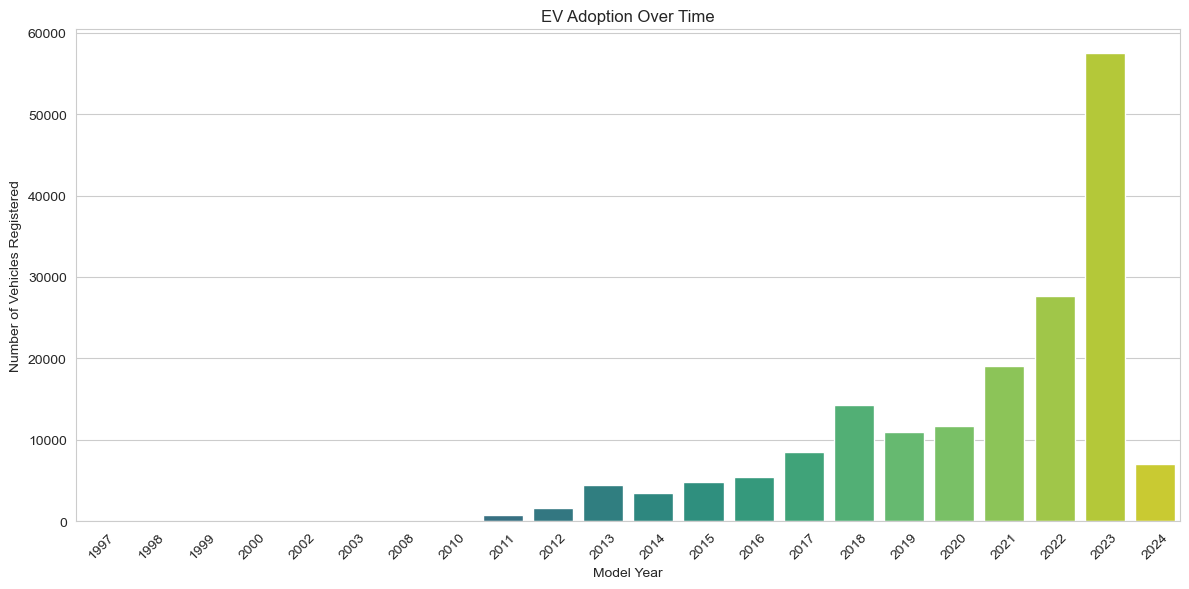

In [7]:
#adoption des vehicule electriques au fil du temps
plt.figure(figsize=(12, 6))
ev_adoption_by_year = ev_data['Model Year'].value_counts().sort_index()
sns.barplot(x=ev_adoption_by_year.index, y=ev_adoption_by_year.values, palette='viridis')
plt.title('EV Adoption Over Time')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicles Registered')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


D'après le graphique à barres ci-dessus, il est clair que l'adoption des véhicules électriques a augmenté au fil du temps, notant notamment une tendance à la hausse significative à partir de 2016 environ. Le nombre de véhicules immatriculés a augmenté modestement jusqu'à cette date, puis a commencé à augmenter plus rapidement à partir de 2017. L'année 2023 montre une augmentation particulièrement forte du nombre de véhicules électriques immatriculés, la barre pour 2023 étant la plus haute du graphique, indiquant un pic d'adoption des véhicules électriques.

Commençons maintenant par sélectionner les 3 premiers comtés en fonction des immatriculations de véhicules électriques, puis analysons la répartition des véhicules électriques dans les villes de ces comtés :

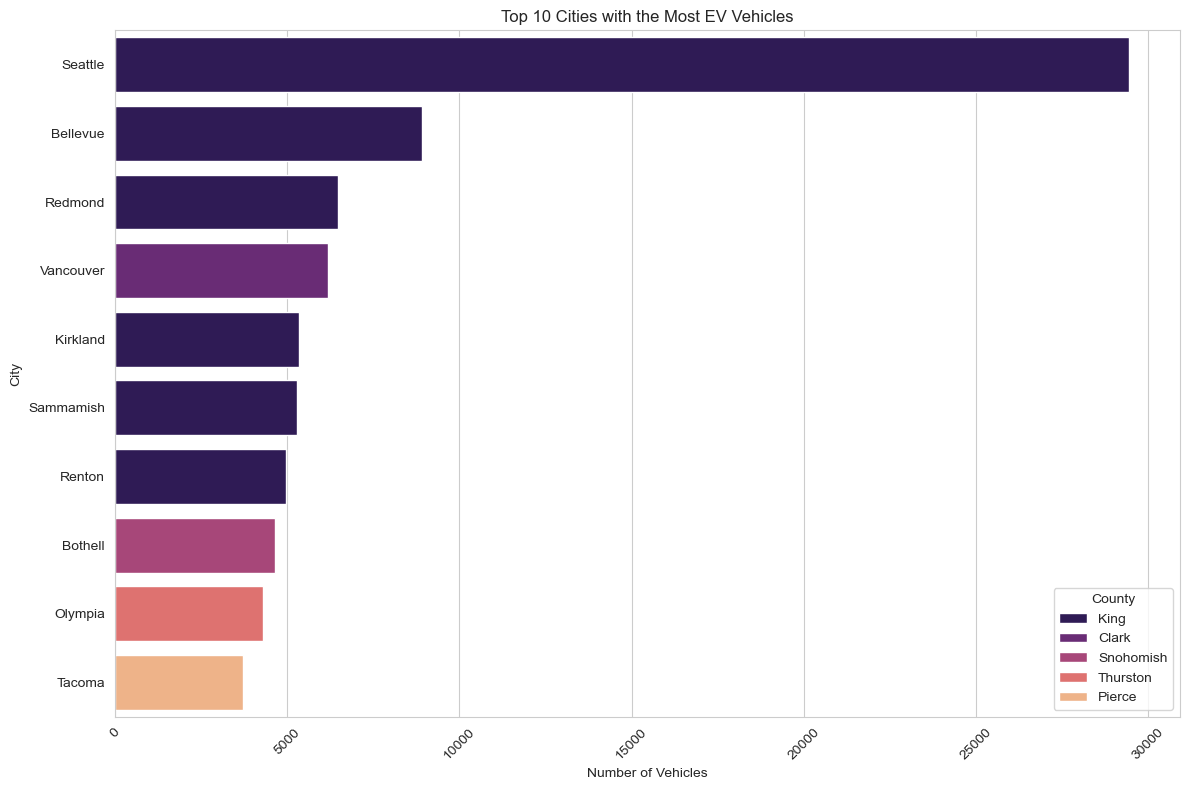

In [8]:
#repartition géographique au niveau du comté
ev_country_distribution = ev_data['County'].value_counts()
top_countries = ev_country_distribution.head(10).index

#filtrage de l'ensemble de données pour cest principaux comtés
top_countries_data = ev_data[ev_data['County'].isin(top_countries)]

#analyser la repartition des vehicules electriques dans les ville de ces principaux comté
ev_city_distribution_top_countries = top_countries_data.groupby(['County', 'City']).size().sort_values(ascending=False).reset_index(name='Number of Vehicule')

#visualisez les 10 premieres villes de ces comtés
top_cities = ev_city_distribution_top_countries.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(y='City', x='Number of Vehicule', hue='County', data=top_cities, palette='magma')
plt.title('Top 10 Cities with the Most EV Vehicles')
plt.xlabel('Number of Vehicles')
plt.ylabel('City')
plt.xticks(rotation=45)
plt.legend(title='County')
plt.tight_layout()
plt.show()

Le graphique ci-dessus compare le nombre de véhicules électriques immatriculés dans différentes villes de trois comtés : King, Snohomish et Pierce. Les barres horizontales représentent les villes et leur longueur correspond au nombre de véhicules immatriculés, codé par couleur par comté. Voici les principaux résultats du graphique ci-dessus :

- Seattle, qui se trouve dans le comté de King, compte le plus grand nombre d'immatriculations de véhicules électriques, de loin, surpassant de loin les autres villes répertoriées.

- Bellevue et Redmond, également dans le comté de King, suivent Seattle avec les immatriculations les plus élevées, bien que celles-ci soient considérablement inférieures à celles de Seattle.

- Les villes du comté de Snohomish, telles que Kirkland et Sammamish, affichent des immatriculations de véhicules électriques modérées.

- Tacoma et Tukwila, représentant le comté de Pierce, ont le moins d'immatriculations de véhicules électriques parmi les villes répertoriées, Tacoma étant légèrement devant Tukwila.

- La majorité des villes présentées sont situées dans le comté de King, qui semble dominer les immatriculations de véhicules électriques parmi les trois comtés.

- Dans l’ensemble, le graphique indique que l’adoption des véhicules électriques n’est pas uniforme dans les villes et est plus concentrée dans certaines zones, en particulier dans le comté de King.

Explorons ensuite les types de véhicules électriques représentés dans cet ensemble de données. Comprendre la répartition entre les différents types de véhicules électriques, tels que les véhicules électriques à batterie (VEB) et les véhicules hybrides rechargeables (VHR), peut nous éclairer sur les préférences des consommateurs et les schémas d'adoption des solutions purement électriques par rapport aux solutions hybrides. Visualisons donc la répartition des types de véhicules électriques pour identifier les catégories les plus populaires parmi les véhicules immatriculés :

C:\Users\moussa.bakayoko\AppData\Local\Temp\ipykernel_22120\165461651.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ev_country_distribution.index, y=ev_country_distribution.values, palette='rocket')


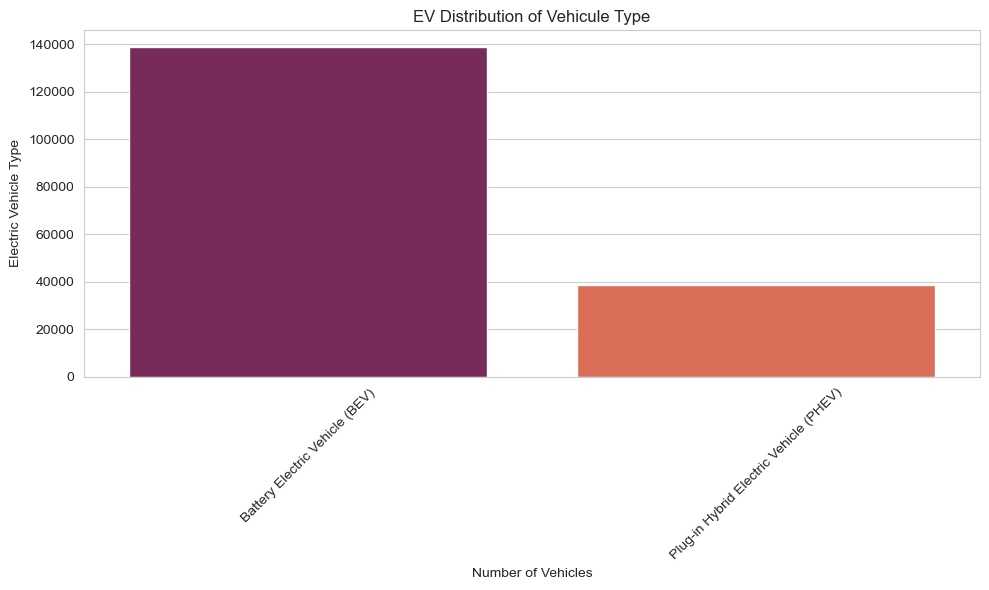

In [9]:
#analyse de la répartition des types de vehicules electriques
ev_country_distribution = ev_data['Electric Vehicle Type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=ev_country_distribution.index, y=ev_country_distribution.values, palette='rocket')
plt.title('EV Distribution of Vehicule Type')
plt.ylabel('Electric Vehicle Type')
plt.xlabel('Number of Vehicles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le graphique ci-dessus montre que les véhicules électriques à batterie sont plus populaires ou préférés que les véhicules hybrides rechargeables parmi les véhicules électriques immatriculés aux États-Unis.

Concentrons-nous maintenant sur la popularité des constructeurs et des modèles de véhicules électriques parmi les véhicules immatriculés. Cette analyse nous aidera à identifier les constructeurs et les modèles spécifiques qui dominent le marché des véhicules électriques, ce qui pourrait indiquer les préférences des consommateurs, la fidélité à la marque et le succès des stratégies des différents constructeurs en matière de promotion de la mobilité électrique.

Alors, examinons les fabricants les plus populaires, puis examinons en détail les modèles les plus populaires au sein de ces fabricants :

C:\Users\moussa.bakayoko\AppData\Local\Temp\ipykernel_22120\4261474006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x=ev_make_distribution.values, y=ev_make_distribution.index, palette='cubehelix')


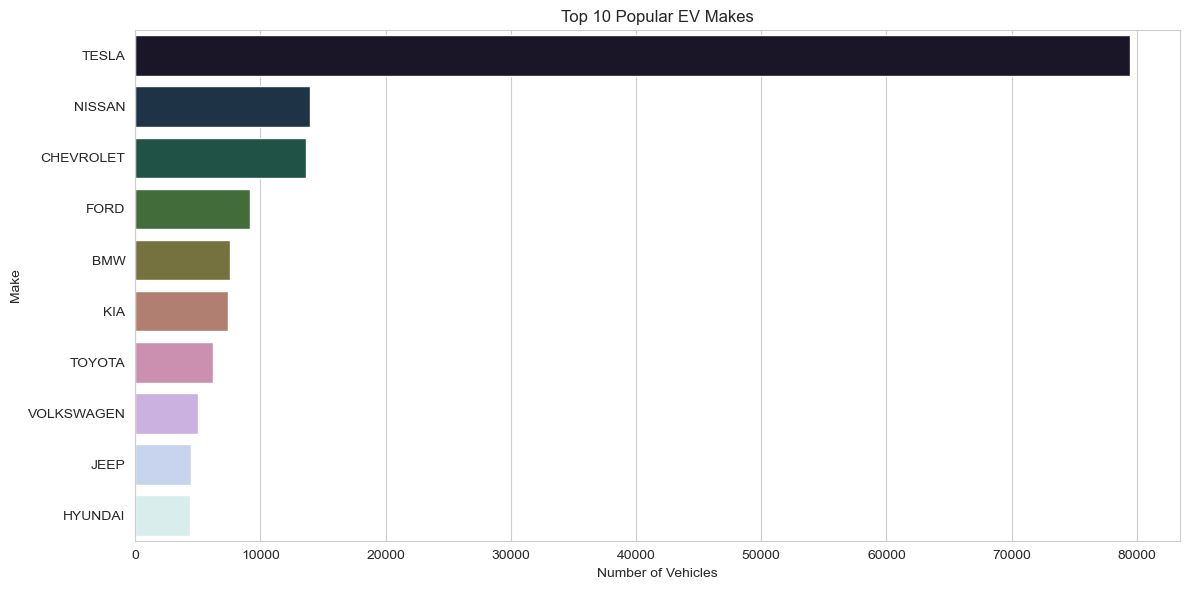

In [10]:
# analyse de la popularité des fabricants de vehicules electriques
ev_make_distribution = ev_data['Make'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot( x=ev_make_distribution.values, y=ev_make_distribution.index, palette='cubehelix')
plt.title('Top 10 Popular EV Makes')
plt.ylabel('Make')
plt.xlabel('Number of Vehicles')
plt.tight_layout()
plt.show()

Le graphique ci-dessus montre que :


- TESLA est en tête avec une marge substantielle, avec le plus grand nombre de véhicules immatriculés.

- NISSAN est le deuxième constructeur le plus populaire, suivi de CHEVROLET, bien que tous deux aient beaucoup moins d'immatriculations que TESLA.

- FORD, BMW, KIA, TOYOTA, VOLKSWAGEN, JEEP et HYUNDAI suivent par ordre décroissant du nombre de véhicules immatriculés.

Ensuite, examinons en détail les modèles les plus populaires de ces grands fabricants pour obtenir une compréhension plus détaillée des préférences des consommateurs au niveau du modèle :

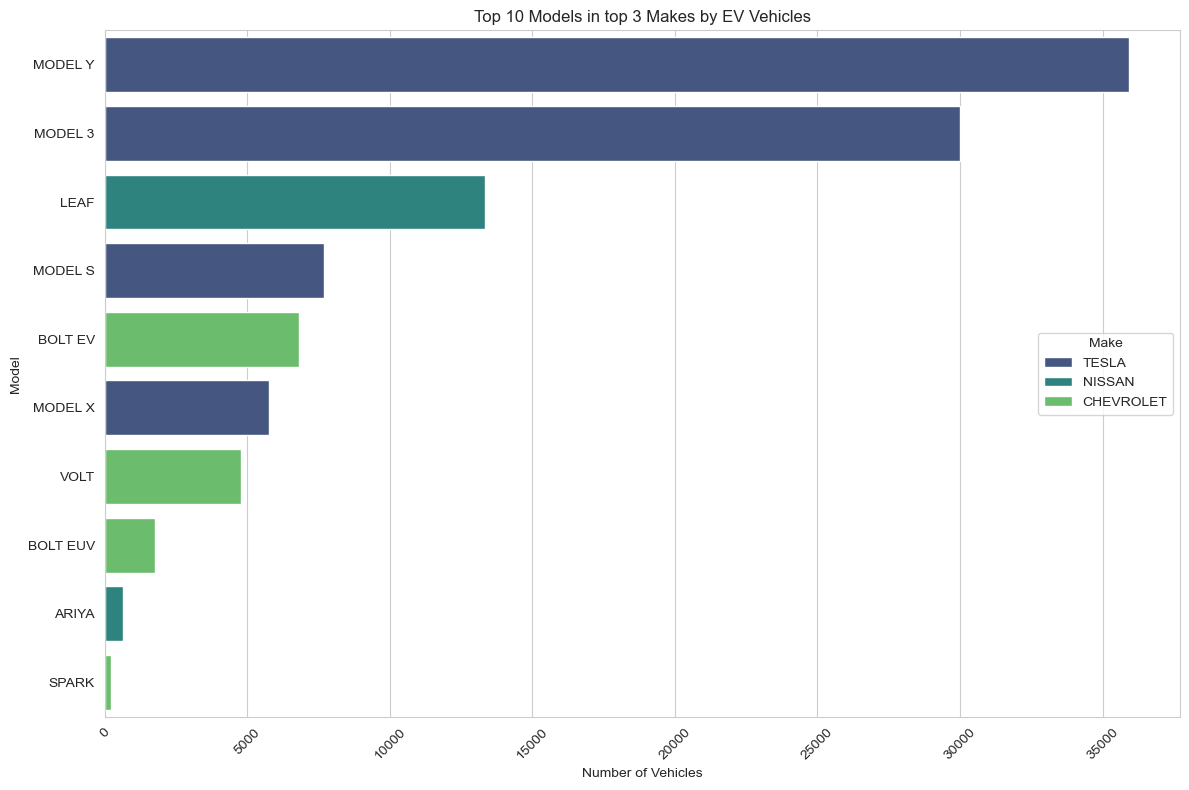

In [11]:
#selection des 3 premiers constructeurs en fonction du nombre de vehicules
top_3_makes = ev_data['Make'].value_counts().head(3).index

#filtrage de l'ensemble de données pour ces principaux fabricants
top_makes_data = ev_data[ev_data['Make'].isin(top_3_makes)]

# analyse de la popularité des modeles de vehicule electrique chez ces grands constructeurs
ev_model_distribution_top_makes = top_makes_data_grouped = top_makes_data.groupby(['Make', 'Model']).size().sort_values(ascending=False).reset_index(name='Number of Vehicles')

#visualiser les 10 meilleurs modele de ces fabricants pour plus de clarté
top_models = ev_model_distribution_top_makes.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(y='Model', x='Number of Vehicles', hue='Make', data=top_models, palette='viridis')
plt.title('Top 10 Models in top 3 Makes by EV Vehicles')
plt.xlabel('Number of Vehicles')
plt.ylabel('Model')
plt.xticks(rotation=45)
plt.legend(title='Make', loc='center right')
plt.tight_layout()
plt.show()

Le graphique ci-dessus montre la répartition des immatriculations de véhicules électriques selon les différents modèles des trois principaux constructeurs : Tesla, Nissan et Chevrolet. Voici les résultats :

- Les modèles TESLA MODEL Y et MODEL 3 sont les véhicules les plus immatriculés, le MODEL Y ayant le plus grand nombre d'immatriculations.

- La LEAF de NISSAN est le troisième modèle le plus immatriculé et le véhicule non-TESLA le plus immatriculé.

- Les modèles MODEL S et MODEL X de TESLA comptent également un nombre important d'immatriculations.

- Les BOLT EV et VOLT de CHEVROLET sont les suivantes dans le classement avec des immatriculations considérables, suivies de BOLT EUV.

- L'ARIYA de NISSAN et la SPARK de CHEVROLET ont le moins d'immatriculations parmi les modèles présentés.

Nous explorerons ensuite l'autonomie électrique des véhicules, un facteur essentiel pour analyser la taille du marché des véhicules électriques. L'autonomie indique la distance qu'un véhicule électrique peut parcourir avec une seule charge, et les progrès technologiques en matière de batteries ont régulièrement augmenté cette autonomie au fil des ans. Examinons donc la répartition des autonomies électriques dans l'ensemble de données et identifions les tendances notables, telles que les améliorations au fil du temps ou les variations entre les différents types de véhicules ou constructeurs.

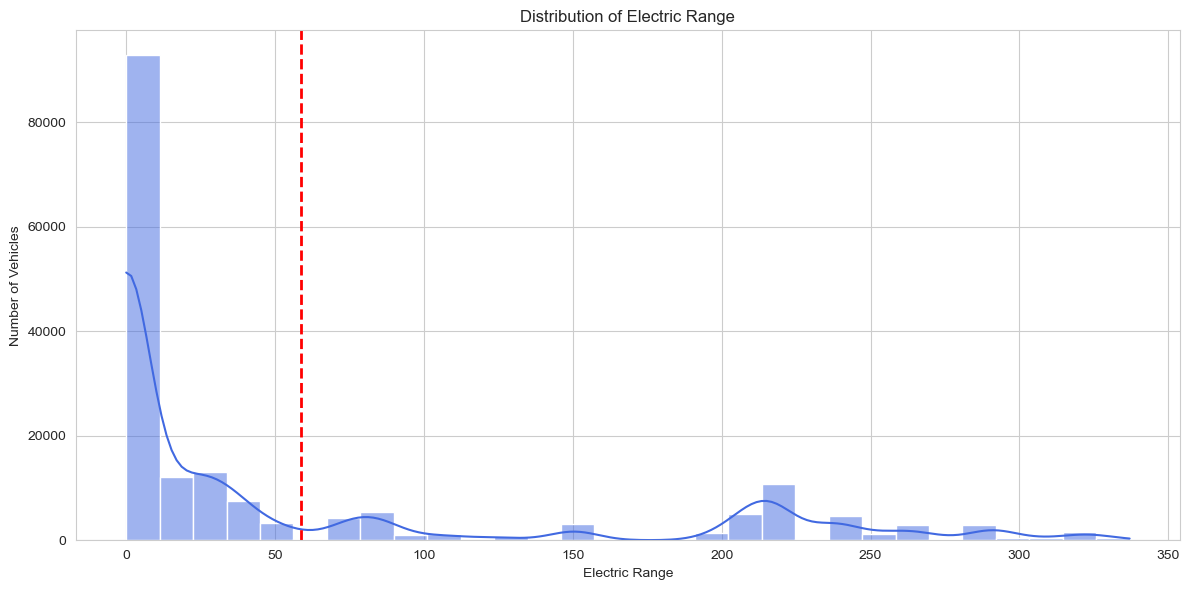

In [12]:
# analyse de la distribution de la portée electrique
plt.figure(figsize=(12, 6))
sns.histplot(ev_data['Electric Range'], bins=30, kde=True, color='royalblue')
plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.axvline(ev_data['Electric Range'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean Range: {ev_data["Electric Range"].mean():.2f}miles')
plt.tight_layout()
plt.show()
#

Le graphique ci-dessus montre l'autonomie électrique moyenne. Les principales observations sont les suivantes :

- On observe une fréquence élevée de véhicules à faible autonomie électrique, avec un pic significatif survenant juste avant 50 miles.

- La distribution est biaisée vers la droite, avec une longue queue s'étendant vers les gammes supérieures, bien que le nombre de véhicules avec des gammes supérieures soit beaucoup moins fréquent.

- L'autonomie électrique moyenne de cet ensemble de véhicules est d'environ 58,84 miles, ce qui est relativement faible par rapport aux autonomies les plus élevées indiquées dans le graphique.

- Malgré la présence de véhicules électriques avec des autonomies allant jusqu'à environ 350 miles, la majorité des véhicules ont une autonomie inférieure à la moyenne.

Cela suggère que même s’il existe des véhicules électriques dotés d’une autonomie électrique élevée, l’autonomie moyenne est biaisée vers le bas en raison d’un nombre important de véhicules dotés d’une autonomie plus courte.

Examinons maintenant l'évolution de l'autonomie électrique au fil des années. Cette analyse peut nous éclairer sur l'influence des progrès technologiques en matière de batteries et de conception des véhicules sur l'autonomie des véhicules électriques au fil du temps. Une tendance positive dans cette analyse indiquerait des améliorations continues, offrant aux consommateurs des véhicules électriques avec une plus grande autonomie et répondant potentiellement à l'une des principales préoccupations du marché des véhicules électriques (l'angoisse de l'autonomie) :

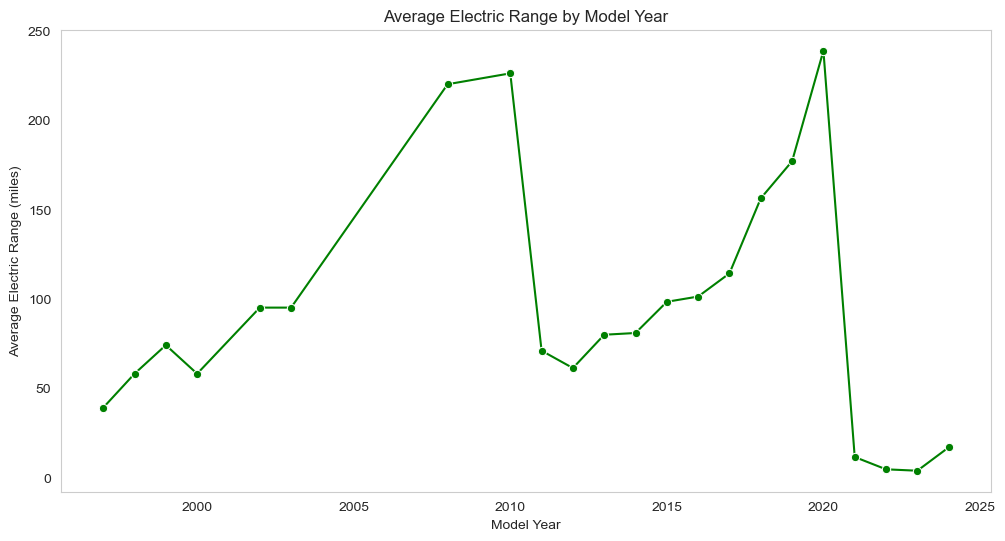

In [13]:
# calcul de l'autonomie electrique moyenne par modèle
average_range_by = ev_data.groupby('Model Year')['Electric Range'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Model Year', y='Electric Range', data=average_range_by, marker='o', color='green')
plt.title('Average Electric Range by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Electric Range (miles)')
plt.grid()
plt.show()

Le graphique ci-dessus montre la progression de l'autonomie électrique moyenne des véhicules entre 2000 et 2024. Principales conclusions du graphique :

- On observe une tendance générale à la hausse de l’autonomie électrique moyenne des véhicules électriques au fil des ans, ce qui indique des améliorations de la technologie et de l’efficacité des batteries.

- On observe un pic notable vers 2020, lorsque la fourchette moyenne atteint son point le plus élevé.
Après 2020, on observe une baisse significative de la gamme moyenne, ce qui pourrait indiquer que les données pour les années suivantes pourraient être incomplètes ou refléter l'introduction de plusieurs modèles de gamme inférieure.

- Après la forte baisse, on observe une légère reprise de la moyenne au cours de l'année la plus récente, comme le montre le graphique.

Les données suggèrent que, malgré certaines fluctuations, la tendance générale au cours des deux dernières décennies a été à l’augmentation de l’autonomie électrique des véhicules électriques.

Examinons maintenant les différences entre les gammes de véhicules électriques des principaux fabricants et modèles. Cette analyse révèle comment les différents fabricants abordent cet aspect crucial de l'autonomie électrique et met en évidence les modèles qui se distinguent par leurs capacités d'autonomie supérieures :

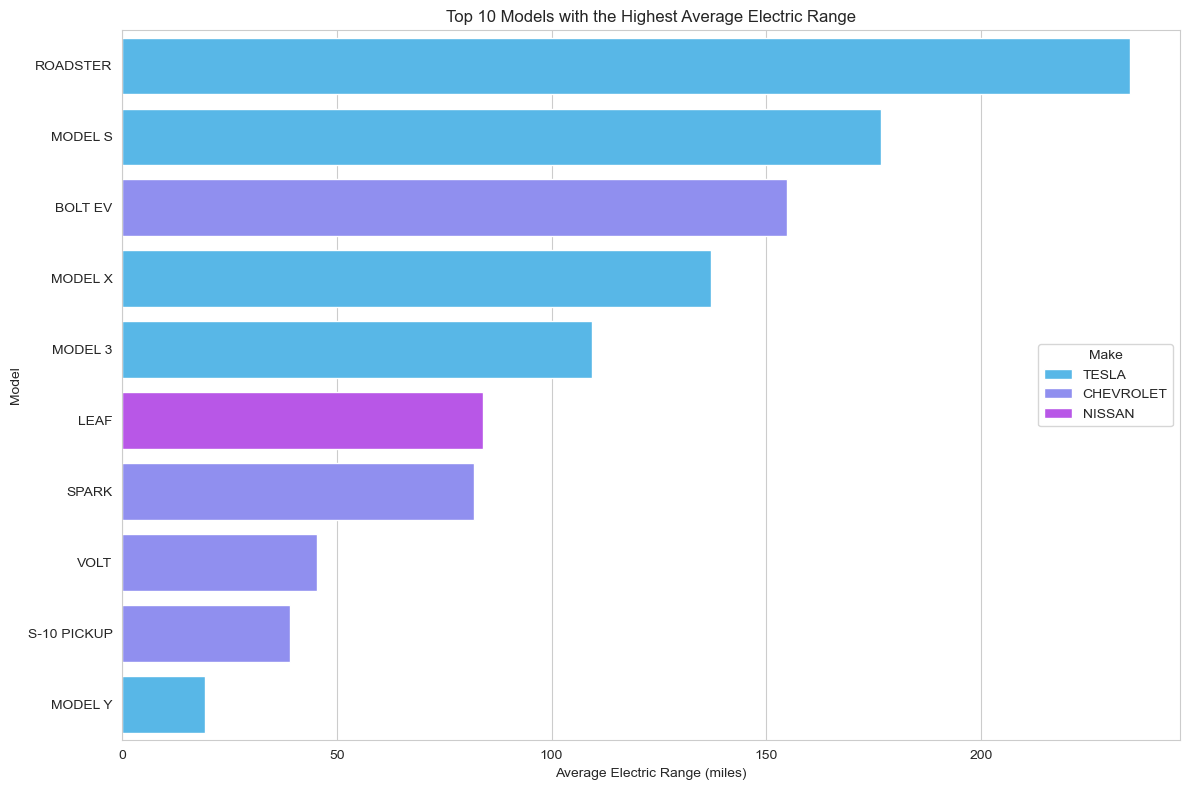

In [14]:
average_range_by_model = top_makes_data.groupby(['Make', 'Model'])['Electric Range'].mean().sort_values(ascending=False).reset_index()

# les 10 meilleurs medeles avec l'autonomie electrique moyenne la plus elevée
top_range_models = average_range_by_model.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='Electric Range', y='Model', hue='Make', data=top_range_models, palette='cool')
plt.title('Top 10 Models with the Highest Average Electric Range')
plt.xlabel('Average Electric Range (miles)')
plt.ylabel('Model')
plt.legend(title='Make', loc='center right')
plt.tight_layout()
plt.show()

La TESLA ROADSTER affiche l'autonomie électrique moyenne la plus élevée parmi les modèles listés. Les modèles TESLA (ROADSTER, MODEL S, MODEL X et MODEL 3) occupent la majorité des premières places, ce qui indique qu'en moyenne, les véhicules TESLA ont une autonomie électrique plus élevée. La CHEVROLET BOLT EV fait figure d'exception parmi les modèles CHEVROLET, avec une autonomie nettement supérieure à celle de la VOLT et du S-10 PICKUP du même constructeur. La LEAF de NISSAN et la SPARK de CHEVROLET se situent dans la moitié inférieure du classement, ce qui suggère des autonomies moyennes plus modestes.

# Analyse de la taille estimée du marché des véhicules électriques aux États-Unis
Passons maintenant à l'estimation de la taille du marché des véhicules électriques aux États-Unis. Je vais d'abord compter le nombre de véhicules électriques immatriculés chaque année :


In [15]:
# calculer le nombre de vehicules electriques immatriculés chaque année
ev_registration_counts = ev_data['Model Year'].value_counts().sort_index()
ev_registration_counts

Model Year
1997        1
1998        1
1999        5
2000        7
2002        2
2003        1
2008       19
2010       23
2011      775
2012     1614
2013     4399
2014     3496
2015     4826
2016     5469
2017     8534
2018    14286
2019    10913
2020    11740
2021    19063
2022    27708
2023    57519
2024     7072
Name: count, dtype: int64

L'ensemble de données indique le nombre de véhicules électriques immatriculés chaque année de 1997 à 2024. Cependant, les données pour 2024 sont incomplètes, car elles ne couvrent que la période allant jusqu'en mars. Voici un résumé des immatriculations de véhicules électriques des dernières années :

- En 2021, 19 063 véhicules électriques ont été immatriculés.
- En 2022, le nombre est passé à 27 708 véhicules électriques.
- En 2023, un bond significatif à 57 519 VE a été observé.
- Pour 2024, actuellement, 7 072 véhicules électriques sont immatriculés, ce qui suggère des données partielles.

Pour prévoir le nombre total de véhicules électriques qui devraient être immatriculés en 2024, nous pouvons utiliser une approche basée sur le taux de croissance des années complètes précédentes.


Nous allons calculer le taux de croissance annuel composé (TCAC) entre une année récente pour laquelle nous disposons de données complètes (2023) et une année antérieure afin de projeter les chiffres de 2024. De plus, ce taux de croissance nous permet d'estimer la taille du marché pour les cinq prochaines années. Procédons aux calculs suivants :

In [16]:
from ast import Param
#filtrer l'ensemble de données pour inclure les années avec des données complètes
filtered_years = ev_registration_counts[ev_registration_counts.index <= 2023]

# définir une fonction de croissance exponentielle pour s'adapter aux données
def exp_growth(x, a, b):
    return a * np.exp(b * x)

#preparer les données pour l'ajustement de la courbe
x_data = filtered_years.index - filtered_years.index.min()
y_data = filtered_years.values

#adapter les données à la fonction de croissance exponentielle
Params, covariance = curve_fit(exp_growth, x_data, y_data)

#utiliser la fonction ajustée pour prévoir le nombre de vehicules electriques pour 2024 et les 5 prochaines années
forcast_years = np.arange(2024, 2024 + 6) - filtered_years.index.min()
forecasted_values = exp_growth(forcast_years, *Params)

# créer un dictionnaire pour afficher les valeurs prevues pour une interpretation plus facile
forecasted_evs = dict(zip(forcast_years + filtered_years.index.min(), forecasted_values))

print(forecasted_evs)

{2024: 79079.20808938889, 2025: 119653.96274428742, 2026: 181047.22020265696, 2027: 273940.74706208805, 2028: 414497.01805382164, 2029: 627171.3128407666}


Maintenant, traçons les données estimées sur la taille du marché :

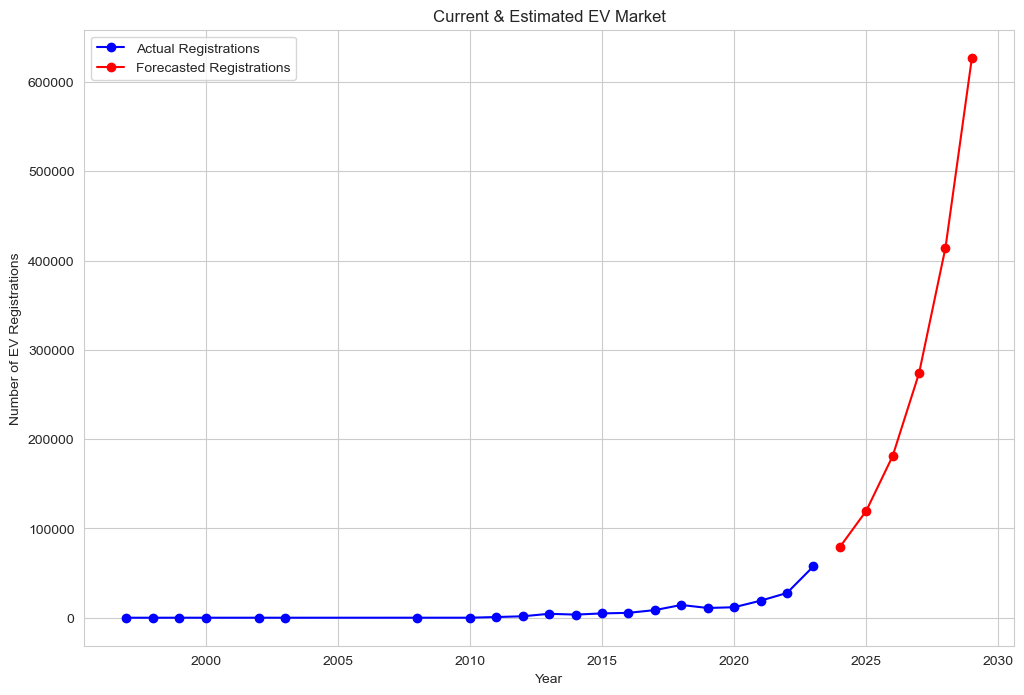

In [17]:
# preparer les données pour le traçage
years = np.arange(filtered_years.index.min(), 2029 + 1)
actual_years = filtered_years.index
forecast_years_full = np.arange(2024, 2029 + 1)

# valeurs réelles et prévues
actual_values = filtered_years.values
forecasted_values_full = [forecasted_evs[year] for year in forecast_years_full]

plt.figure(figsize=(12, 8))
plt.plot(actual_years, actual_values, 'bo-', label='Actual Registrations')
plt.plot(forecast_years_full, forecasted_values_full, 'ro-', label='Forecasted Registrations')

plt.title('Current & Estimated EV Market')
plt.xlabel('Year')
plt.ylabel('Number of EV Registrations')
plt.legend()
plt.grid(True)
plt.show()


D'après le graphique ci-dessus, nous pouvons voir :

- Le nombre d’immatriculations de véhicules électriques est resté relativement faible et stable jusqu’en 2010 environ, après quoi on a observé une tendance à la hausse constante et marquée, suggérant une augmentation significative de l’adoption des véhicules électriques.

- Les prévisions d’immatriculations de véhicules électriques prévoient une augmentation encore plus spectaculaire dans un avenir proche, le nombre d’immatriculations devant augmenter fortement dans les années à venir.

Compte tenu de la tendance à la hausse des immatriculations de véhicules électriques et de l'accélération prévue par les données prévisionnelles, nous pouvons conclure que le marché des véhicules électriques devrait connaître une expansion considérable. La forte hausse des immatriculations prévues suggère une adoption croissante des véhicules électriques par les consommateurs, et cette tendance devrait se poursuivre. Globalement, les données laissent entrevoir un avenir prometteur pour le secteur des véhicules électriques, indiquant une évolution significative des préférences des consommateurs et une augmentation potentielle des investissements et des opportunités commerciales.

# Résumé
L'analyse de la taille du marché est donc un aspect crucial des études de marché, car elle permet de déterminer le volume de ventes potentiel d'un marché donné. Elle aide les entreprises à comprendre l'ampleur de la demande, à évaluer les niveaux de saturation du marché et à identifier les opportunités de croissance. Notre analyse de la taille du marché des véhicules électriques révèle un avenir prometteur pour le secteur, indiquant une évolution significative des préférences des consommateurs et une augmentation potentielle des investissements et des opportunités commerciales.